In [1]:
#! pip install --upgrade xarray zarr gcsfs cftime nc-time-axis

In [2]:
#! pip install xarray zarr gcsfs

In [3]:
#
#pip install dask


In [4]:
#pip install scipy

In [5]:
from scipy.spatial import cKDTree


In [6]:
import numpy as np
import pandas as pd
import xarray as xr
import zarr
import gcsfs
import matplotlib.pyplot as plt
import dask

%matplotlib inline


xr.set_options(display_style='html')
%config InlineBackend.figure_format = 'retina' 

In [7]:
plt.rcParams['figure.figsize'] = 12, 6

In [8]:
df = pd.read_csv('https://storage.googleapis.com/cmip6/cmip6-zarr-consolidated-stores.csv')
df.head()

,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,zstore,dcpp_init_year,version
0,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,ps,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
1,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rsds,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
2,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rlus,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
3,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rlds,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
4,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,psl,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706


In [9]:
historical_precipitation = df[
   (df['institution_id'] == 'NCAR') &
   (df['source_id'] == 'CESM2') &
   (df['member_id'] == 'r11i1p1f1') &
   (df['activity_id'] == 'CMIP') &
   (df['experiment_id'] == 'historical') &
   (df['variable_id'].isin(['pr'])) &
   (df['table_id'].isin(['Amon'])) 
]
historical_precipitation

,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,zstore,dcpp_init_year,version
200657,CMIP,NCAR,CESM2,historical,r11i1p1f1,Amon,pr,gn,gs://cmip6/CMIP6/CMIP/NCAR/CESM2/historical/r1...,NaN,20190514


In [10]:
# Load historical precipitation data
gcs = gcsfs.GCSFileSystem(token='anon')

# Get the path
zstore = historical_precipitation.zstore.values[0]

# Open the dataset
ds_historical = xr.open_zarr(gcs.get_mapper(zstore), consolidated=True)
ds_historical

<xarray.Dataset> Size: 438MB
Dimensions:    (time: 1980, lat: 192, lon: 288, nbnd: 2)
Coordinates:
  * time       (time) object 16kB 1850-01-15 12:00:00 ... 2014-12-15 12:00:00
  * lat        (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon        (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
    lat_bnds   (lat, nbnd) float64 3kB dask.array<chunksize=(192, 2), meta=np.ndarray>
    lon_bnds   (lon, nbnd) float64 5kB dask.array<chunksize=(288, 2), meta=np.ndarray>
    time_bnds  (time, nbnd) object 32kB dask.array<chunksize=(1980, 2), meta=np.ndarray>
Dimensions without coordinates: nbnd
Data variables:
    pr         (time, lat, lon) float32 438MB dask.array<chunksize=(600, 192, 288), meta=np.ndarray>
Attributes: (12/47)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   674885.0
    branch_time_in_parent:  219000.0
    case_id:                972
    ...                     ...
    table_id:               Amon
    tracking_id:            hdl:21.14100/72897fd8-3516-431d-a1b1-c083130871a7...
    variable_id:            pr
    variant_info:           CMIP6 20th century experiments (1850-2014) with C...
    variant_label:          r11i1p1f1
    status:                 2019-10-25;created;by nhn2@columbia.edu

In [11]:
ds_historical['time'] = ds_historical.indexes['time'].to_datetimeindex()

/var/folders/yf/rphrjvld5m9f1mf5tfgxhc3c0000gn/T/ipykernel_1467/1874523615.py:1: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the `time_unit` keyword argument.
  ds_historical['time'] = ds_historical.indexes['time'].to_datetimeindex()
/var/folders/yf/rphrjvld5m9f1mf5tfgxhc3c0000gn/T/ipykernel_1467/1874523615.py:1: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  ds_historical['time'] = ds_historical.indexes['time'].to_datetimeindex()


In [12]:
# Drop unnecessary coordinates and create 'year' coordinate
ds_historical = ds_historical.assign_coords(
    year = ds_historical.time.dt.year
)
ds_historical = ds_historical.drop_vars(['time', 'lat_bnds', 'lon_bnds', 'time_bnds'])
ds_historical

<xarray.Dataset> Size: 438MB
Dimensions:  (time: 1980, lat: 192, lon: 288)
Coordinates:
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
    year     (time) int64 16kB 1850 1850 1850 1850 1850 ... 2014 2014 2014 2014
Dimensions without coordinates: time
Data variables:
    pr       (time, lat, lon) float32 438MB dask.array<chunksize=(600, 192, 288), meta=np.ndarray>
Attributes: (12/47)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   674885.0
    branch_time_in_parent:  219000.0
    case_id:                972
    ...                     ...
    table_id:               Amon
    tracking_id:            hdl:21.14100/72897fd8-3516-431d-a1b1-c083130871a7...
    variable_id:            pr
    variant_info:           CMIP6 20th century experiments (1850-2014) with C...
    variant_label:          r11i1p1f1
    status:                 2019-10-25;created;by nhn2@columbia.edu

In [13]:
# Return the precipitation for each lon and lat grouped by year
his_annual_precip = ds_historical.groupby('year').mean(dim='time')
his_annual_precip

<xarray.Dataset> Size: 37MB
Dimensions:  (year: 165, lat: 192, lon: 288)
Coordinates:
  * year     (year) int64 1kB 1850 1851 1852 1853 1854 ... 2011 2012 2013 2014
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
Data variables:
    pr       (year, lat, lon) float32 36MB dask.array<chunksize=(1, 192, 288), meta=np.ndarray>
Attributes: (12/47)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   674885.0
    branch_time_in_parent:  219000.0
    case_id:                972
    ...                     ...
    table_id:               Amon
    tracking_id:            hdl:21.14100/72897fd8-3516-431d-a1b1-c083130871a7...
    variable_id:            pr
    variant_info:           CMIP6 20th century experiments (1850-2014) with C...
    variant_label:          r11i1p1f1
    status:                 2019-10-25;created;by nhn2@columbia.edu

In [14]:
# Compute cleaned historical precipitation dataframe
historical_precipitation_df = his_annual_precip.to_dataframe().reset_index()  
historical_precipitation_df

,year,lat,lon,pr
0,1850,-90.0,0.00,0.000002
1,1850,-90.0,1.25,0.000002
2,1850,-90.0,2.50,0.000002
3,1850,-90.0,3.75,0.000002
4,1850,-90.0,5.00,0.000002
...,...,...,...,...
9123835,2014,90.0,353.75,0.000008
9123836,2014,90.0,355.00,0.000008
9123837,2014,90.0,356.25,0.000008
9123838,2014,90.0,357.50,0.000008


In [ ]:
future_precipitation = df[
   (df['activity_id'] == 'ScenarioMIP') &
   (df['institution_id'] == 'NCAR') &
   (df['source_id'] == 'CESM2') &
   (df['member_id'] == 'r11i1p1f1') &
   (df['experiment_id'] == 'ssp126') &
   (df['variable_id'].isin(['pr'])) &
   (df['table_id'].isin(['Amon'])) 
]
future_precipitation

,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,zstore,dcpp_init_year,version
446067,ScenarioMIP,NCAR,CESM2,ssp245,r11i1p1f1,Amon,pr,gn,gs://cmip6/CMIP6/ScenarioMIP/NCAR/CESM2/ssp245...,NaN,20200528


In [16]:
# Load future precipitation data
gcs = gcsfs.GCSFileSystem(token='anon')
zstore = future_precipitation.zstore.values[0]
ds_future = xr.open_zarr(gcs.get_mapper(zstore), consolidated=True, chunks={'time': 12})
ds_future

/var/folders/yf/rphrjvld5m9f1mf5tfgxhc3c0000gn/T/ipykernel_1467/1920609503.py:4: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 12. This could degrade performance. Instead, consider rechunking after loading.
  ds_future = xr.open_zarr(gcs.get_mapper(zstore), consolidated=True, chunks={'time': 12})


<xarray.Dataset> Size: 228MB
Dimensions:    (time: 1032, lat: 192, lon: 288, nbnd: 2)
Coordinates:
  * time       (time) object 8kB 2015-01-15 12:00:00 ... 2100-12-15 12:00:00
  * lat        (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon        (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
    lat_bnds   (lat, nbnd) float64 3kB dask.array<chunksize=(192, 2), meta=np.ndarray>
    lon_bnds   (lon, nbnd) float64 5kB dask.array<chunksize=(288, 2), meta=np.ndarray>
    time_bnds  (time, nbnd) object 17kB dask.array<chunksize=(12, 2), meta=np.ndarray>
Dimensions without coordinates: nbnd
Data variables:
    pr         (time, lat, lon) float32 228MB dask.array<chunksize=(12, 192, 288), meta=np.ndarray>
Attributes: (12/46)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            ScenarioMIP
    branch_method:          standard
    branch_time_in_child:   735110.0
    branch_time_in_parent:  735110.0
    case_id:                1731
    ...                     ...
    sub_experiment_id:      none
    table_id:               Amon
    tracking_id:            hdl:21.14100/077f7679-2555-431e-a864-29011759e8e7...
    variable_id:            pr
    variant_info:           CMIP6 SSP2-4.5 experiments (2015-2100) with CAM6,...
    variant_label:          r11i1p1f1

In [17]:
ds_future['time'] = ds_future.indexes['time'].to_datetimeindex()

/var/folders/yf/rphrjvld5m9f1mf5tfgxhc3c0000gn/T/ipykernel_1467/1372549677.py:1: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the `time_unit` keyword argument.
  ds_future['time'] = ds_future.indexes['time'].to_datetimeindex()
/var/folders/yf/rphrjvld5m9f1mf5tfgxhc3c0000gn/T/ipykernel_1467/1372549677.py:1: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  ds_future['time'] = ds_future.indexes['time'].to_datetimeindex()


In [18]:
# Drop unnecessary coordinates and create 'year' coordinate
ds_future = ds_future.assign_coords(
    year = ds_future.time.dt.year
)
ds_future = ds_future.drop_vars(['time', 'lat_bnds', 'lon_bnds', 'time_bnds'])
ds_future

<xarray.Dataset> Size: 228MB
Dimensions:  (time: 1032, lat: 192, lon: 288)
Coordinates:
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
    year     (time) int64 8kB 2015 2015 2015 2015 2015 ... 2100 2100 2100 2100
Dimensions without coordinates: time
Data variables:
    pr       (time, lat, lon) float32 228MB dask.array<chunksize=(12, 192, 288), meta=np.ndarray>
Attributes: (12/46)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            ScenarioMIP
    branch_method:          standard
    branch_time_in_child:   735110.0
    branch_time_in_parent:  735110.0
    case_id:                1731
    ...                     ...
    sub_experiment_id:      none
    table_id:               Amon
    tracking_id:            hdl:21.14100/077f7679-2555-431e-a864-29011759e8e7...
    variable_id:            pr
    variant_info:           CMIP6 SSP2-4.5 experiments (2015-2100) with CAM6,...
    variant_label:          r11i1p1f1

In [19]:
# Return the precipitation for each lon and lat grouped by year
future_annual_precip = ds_future.groupby('year').mean(dim='time')
future_annual_precip

<xarray.Dataset> Size: 19MB
Dimensions:  (year: 86, lat: 192, lon: 288)
Coordinates:
  * year     (year) int64 688B 2015 2016 2017 2018 2019 ... 2097 2098 2099 2100
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
Data variables:
    pr       (year, lat, lon) float32 19MB dask.array<chunksize=(1, 192, 288), meta=np.ndarray>
Attributes: (12/46)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            ScenarioMIP
    branch_method:          standard
    branch_time_in_child:   735110.0
    branch_time_in_parent:  735110.0
    case_id:                1731
    ...                     ...
    sub_experiment_id:      none
    table_id:               Amon
    tracking_id:            hdl:21.14100/077f7679-2555-431e-a864-29011759e8e7...
    variable_id:            pr
    variant_info:           CMIP6 SSP2-4.5 experiments (2015-2100) with CAM6,...
    variant_label:          r11i1p1f1

**CATEGORIZE LAT AND LON BASED ON CITIES**

In [20]:
cities = pd.read_csv('uscities.csv')

In [21]:
#keep only city, lat, lon, population
cities = cities[['city', 'lat', 'lng', 'population']]
cities = cities.rename(columns={'lng': 'lon'})
cities.head()

,city,lat,lon,population
0,New York,40.6943,-73.9249,18713220
1,Los Angeles,34.1139,-118.4068,12750807
2,Chicago,41.8373,-87.6862,8604203
3,Miami,25.7839,-80.2102,6445545
4,Dallas,32.7936,-96.7662,5743938


## Mapping future_annual_precip to cities

In [22]:

lon_values = np.linspace(-180, 180, future_annual_precip.dims["lon"])

future_annual_precip = future_annual_precip.assign_coords(lon=lon_values)

/var/folders/yf/rphrjvld5m9f1mf5tfgxhc3c0000gn/T/ipykernel_1467/2308203933.py:1: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  lon_values = np.linspace(-180, 180, future_annual_precip.dims["lon"])


In [23]:
print(cities.columns)

Index(['city', 'lat', 'lon', 'population'], dtype='object')


In [24]:
lats = xr.DataArray(cities['lat'], dims="city")
lons = xr.DataArray(cities['lon'], dims="city")

city_precip = future_annual_precip['pr'].sel(lat=lats, lon=lons, method='nearest')


In [25]:
city_precip


<xarray.DataArray 'pr' (year: 86, city: 28338)> Size: 10MB
dask.array<transpose, shape=(86, 28338), dtype=float32, chunksize=(1, 28338), chunktype=numpy.ndarray>
Coordinates:
  * year     (year) int64 688B 2015 2016 2017 2018 2019 ... 2097 2098 2099 2100
  * city     (city) int64 227kB 0 1 2 3 4 5 ... 28333 28334 28335 28336 28337
    lat      (city) float64 227kB 40.99 34.4 41.94 25.92 ... 47.59 36.28 42.88
    lon      (city) float64 227kB -73.38 -118.5 -87.18 ... -95.96 -95.96 -98.47
Attributes: (12/19)
    cell_measures:  area: areacella
    cell_methods:   area: time: mean
    comment:        chunits( ((1000 * PRECT)), units="kg m-2 s-1")
    description:    at surface; includes both liquid and solid phases from al...
    frequency:      mon
    id:             pr
    ...             ...
    time_label:     time-mean
    time_title:     Temporal mean
    title:          Precipitation
    type:           real
    units:          kg m-2 s-1
    variable_id:    pr

In [26]:
city_precip_df = city_precip.to_dataframe(name='pr').reset_index()

In [27]:
cities_precip = cities.merge(
    city_precip_df,
    left_index=True,     
    right_on="city",
    how="left"
)
cities_precip

,city,city_x,lat_x,lon_x,population,year,city_y,lat_y,lon_y,pr
0,0,New York,40.6943,-73.9249,18713220,2015,0,40.994764,-73.379791,0.000009
28338,0,New York,40.6943,-73.9249,18713220,2016,0,40.994764,-73.379791,0.000006
56676,0,New York,40.6943,-73.9249,18713220,2017,0,40.994764,-73.379791,0.000007
85014,0,New York,40.6943,-73.9249,18713220,2018,0,40.994764,-73.379791,0.000008
113352,0,New York,40.6943,-73.9249,18713220,2019,0,40.994764,-73.379791,0.000008
...,...,...,...,...,...,...,...,...,...,...
2323715,28337,Monowi,42.8307,-98.3296,1,2096,28337,42.879581,-98.466899,0.000012
2352053,28337,Monowi,42.8307,-98.3296,1,2097,28337,42.879581,-98.466899,0.000011
2380391,28337,Monowi,42.8307,-98.3296,1,2098,28337,42.879581,-98.466899,0.000013
2408729,28337,Monowi,42.8307,-98.3296,1,2099,28337,42.879581,-98.466899,0.000013


In [ ]:
annual_precip = ds_historical.groupby('year').mean(dim='time')

In [ ]:
northeast = his_annual_precip.sel(lat=slice(38,47), lon=slice(-80,-66))
south = his_annual_precip.sel(lat=slice(24,39), lon=slice(-106,-75))
midwest = his_annual_precip.sel(lat=slice(36,49), lon=slice(-104,-80))
west = his_annual_precip.sel(lat=slice(31,49), lon=slice(-125,-102))

In [28]:
cities_precip = cities_precip[['city', 'city_x', 'population', 'year', 'pr']]

cities_precip = cities_precip.rename(columns={
    'city_x': 'city_name',
    'lat_x': 'city_lat',
    'lon_x': 'city_lon',
    'pr': 'precip'
})

cities_precip

,city,city_name,population,year,precip
0,0,New York,18713220,2015,0.000009
28338,0,New York,18713220,2016,0.000006
56676,0,New York,18713220,2017,0.000007
85014,0,New York,18713220,2018,0.000008
113352,0,New York,18713220,2019,0.000008
...,...,...,...,...,...
2323715,28337,Monowi,1,2096,0.000012
2352053,28337,Monowi,1,2097,0.000011
2380391,28337,Monowi,1,2098,0.000013
2408729,28337,Monowi,1,2099,0.000013


In [29]:
cities_precip_filtered = cities_precip[cities_precip['population'] > 100_000]

In [30]:
cities_precip_filtered.to_csv("us_cities_precipitation_filtered.csv", index=False)

In [31]:
#convert longitudes to -180 to 180 range
historical_precipitation_df['lon'] = ((historical_precipitation_df['lon'] + 180) % 360) - 180
historical_precipitation_df

,year,lat,lon,pr
0,1850,-90.0,0.00,0.000002
1,1850,-90.0,1.25,0.000002
2,1850,-90.0,2.50,0.000002
3,1850,-90.0,3.75,0.000002
4,1850,-90.0,5.00,0.000002
...,...,...,...,...
9123835,2014,90.0,-6.25,0.000008
9123836,2014,90.0,-5.00,0.000008
9123837,2014,90.0,-3.75,0.000008
9123838,2014,90.0,-2.50,0.000008


In [32]:
us_historical = historical_precipitation_df[
    (historical_precipitation_df['lat'] >= 24) &
    (historical_precipitation_df['lat'] <= 50) &
    (historical_precipitation_df['lon'] >= -125) &
    (historical_precipitation_df['lon'] <= -66)
].copy()

In [33]:
us_historical.reset_index(drop=True, inplace=True)
us_historical

,year,lat,lon,pr
0,1850,24.031414,-125.00,0.000009
1,1850,24.031414,-123.75,0.000007
2,1850,24.031414,-122.50,0.000006
3,1850,24.031414,-121.25,0.000005
4,1850,24.031414,-120.00,0.000006
...,...,...,...,...
221755,2014,49.476440,-71.25,0.000038
221756,2014,49.476440,-70.00,0.000039
221757,2014,49.476440,-68.75,0.000039
221758,2014,49.476440,-67.50,0.000039


**Historical precipitation df with city column**

In [34]:
from scipy.spatial import cKDTree
import numpy as np

grid_points = np.vstack((us_historical['lat'], us_historical['lon'])).T
city_points = np.vstack((cities['lat'], cities['lon'])).T

tree = cKDTree(city_points)
dist, idx = tree.query(grid_points, k=1)

us_historical['city'] = cities.iloc[idx]['city'].values
us_historical

,year,lat,lon,pr,city
0,1850,24.031414,-125.00,0.000009,Avalon
1,1850,24.031414,-123.75,0.000007,Avalon
2,1850,24.031414,-122.50,0.000006,Imperial Beach
3,1850,24.031414,-121.25,0.000005,Imperial Beach
4,1850,24.031414,-120.00,0.000006,Imperial Beach
...,...,...,...,...,...
221755,2014,49.476440,-71.25,0.000038,Caribou
221756,2014,49.476440,-70.00,0.000039,Caribou
221757,2014,49.476440,-68.75,0.000039,Caribou
221758,2014,49.476440,-67.50,0.000039,Caribou


In [35]:
# Compute city-year mean precipitation
us_historical = (
    us_historical
    .groupby(['city', 'year'])
    ['pr'].mean()
    .reset_index()
)

In [36]:
us_historical[us_historical['city']=='San Diego']

,city,year,pr


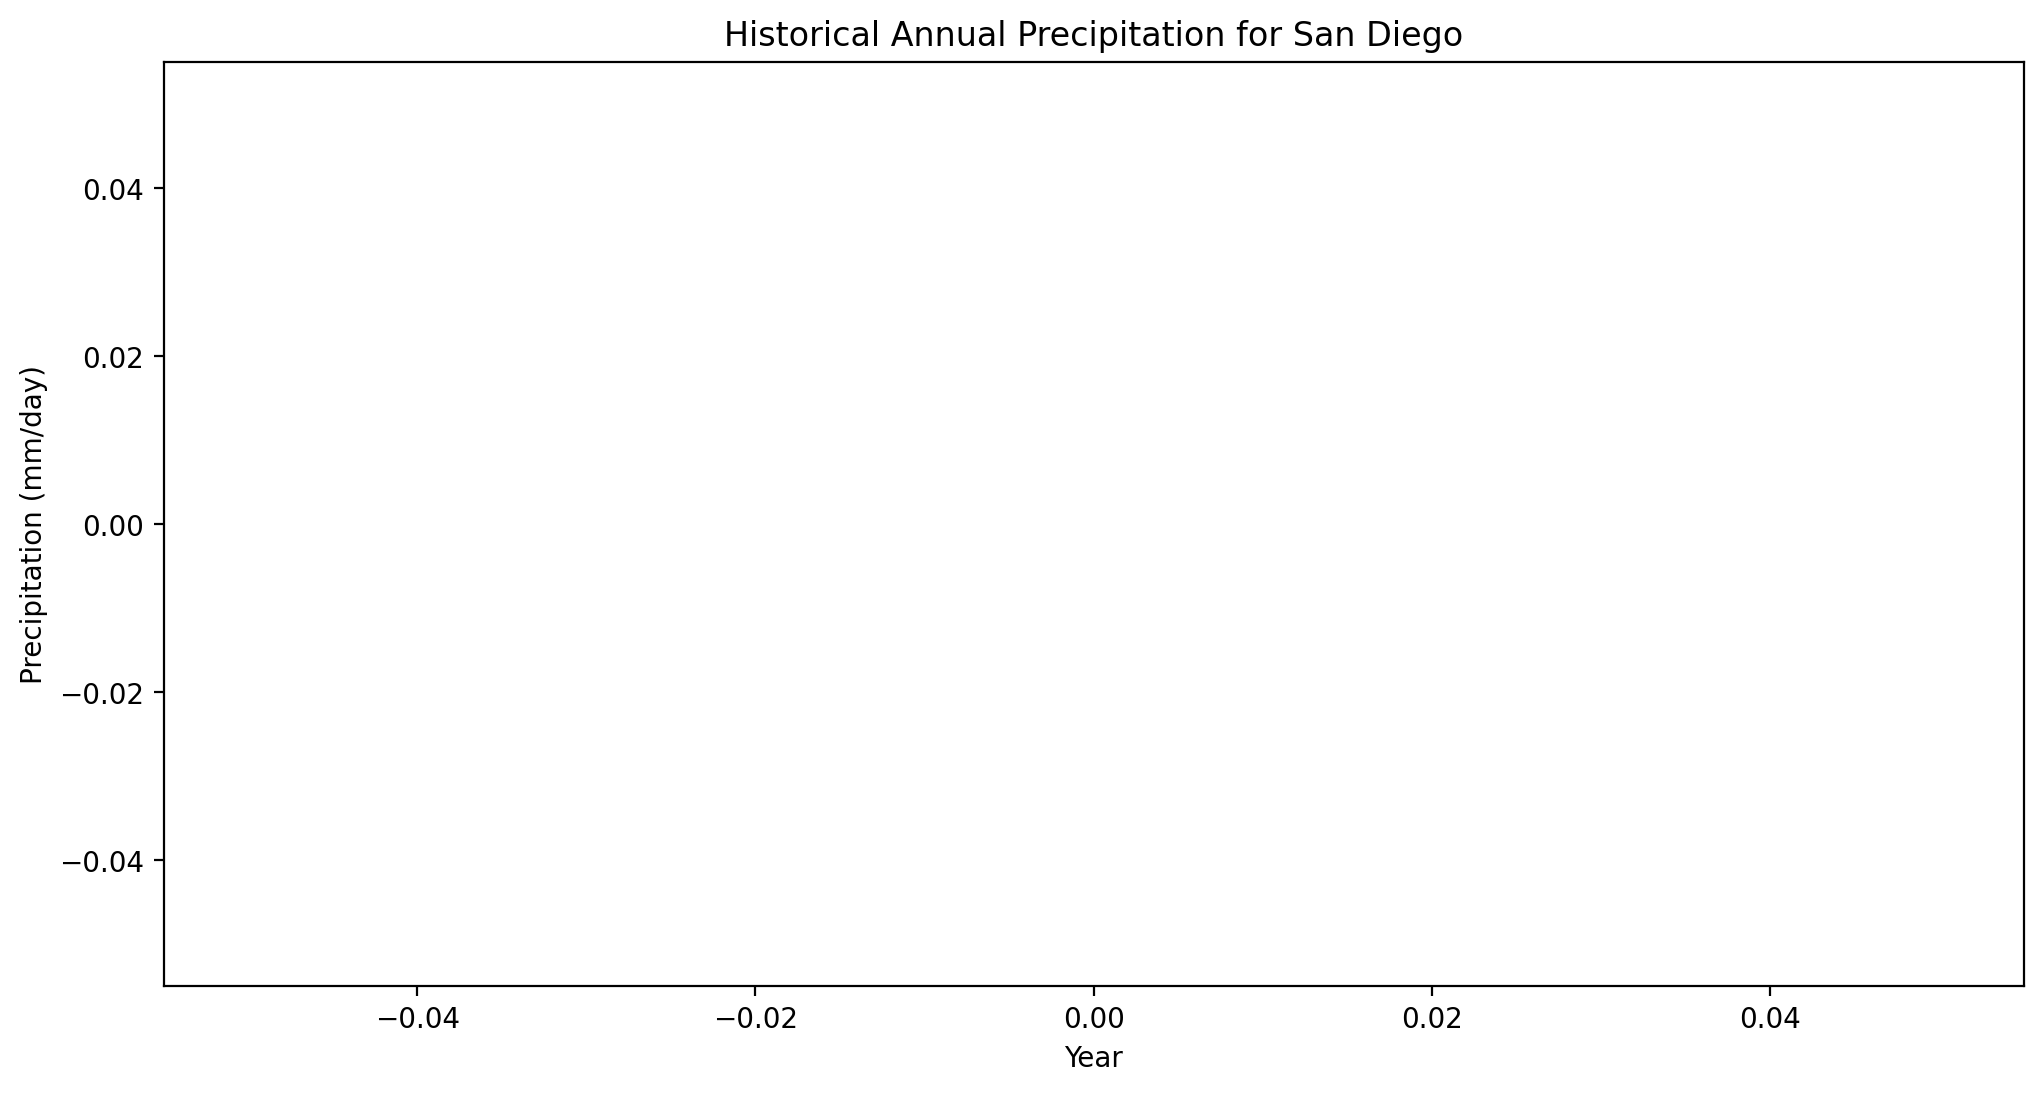

In [37]:
#visualize historical annual precipitation for San Diego
sd_historical = us_historical[us_historical['city']=='San Diego']
plt.plot(sd_historical['year'], sd_historical['pr']*86400)
plt.title('Historical Annual Precipitation for San Diego')
plt.xlabel('Year')
plt.ylabel('Precipitation (mm/day)')
plt.show()